<a href="https://colab.research.google.com/github/reyalejandro453-dot/DeepLearning/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6363 - loss: 0.7625 - val_accuracy: 0.7150 - val_loss: 0.5409
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8087 - loss: 0.4612 - val_accuracy: 0.8450 - val_loss: 0.4085
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8838 - loss: 0.3567 - val_accuracy: 0.8800 - val_loss: 0.3333
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9025 - loss: 0.2957 - val_accuracy: 0.8900 - val_loss: 0.2896
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9187 - loss: 0.2511 - val_accuracy: 0.8950 - val_loss: 0.2522
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9250 - loss: 0.2201 - val_accuracy: 0.9150 - val_loss: 0.2330
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9362 - loss: 0.1910 - val_accuracy: 0.9200 - val_loss: 0.2079
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9450 - loss: 0.1702 - val_accuracy: 0.9250 - val_loss: 0.1992
Ep

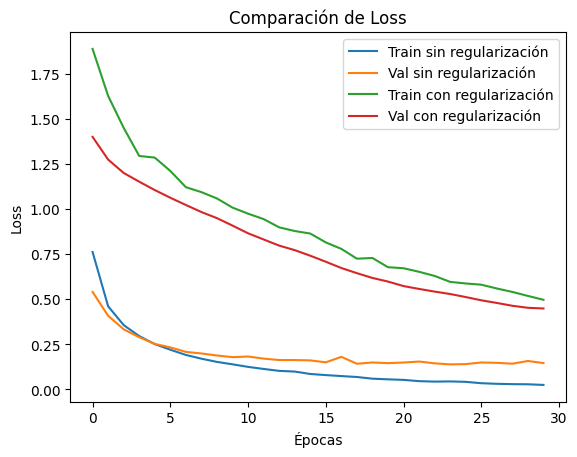

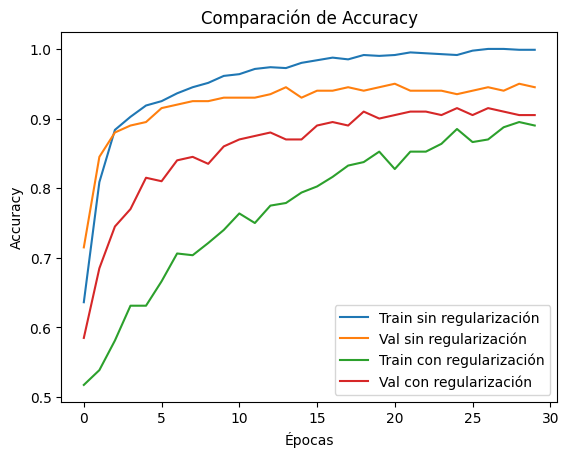

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
X, y = make_classification(n_samples=1000, n_features=20,
                           n_informative=15, n_redundant=5,
                           random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model_base = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_base.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

history_base = model_base.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                             epochs=30,
                             batch_size=32,
                             verbose=1)
model_reg = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(20,)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_reg = model_reg.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=30,
                           batch_size=32,
                           verbose=1)
plt.figure()
plt.plot(history_base.history['loss'], label='Train sin regularización')
plt.plot(history_base.history['val_loss'], label='Val sin regularización')

plt.plot(history_reg.history['loss'], label='Train con regularización')
plt.plot(history_reg.history['val_loss'], label='Val con regularización')

plt.title('Comparación de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.figure()
plt.plot(history_base.history['accuracy'], label='Train sin regularización')
plt.plot(history_base.history['val_accuracy'], label='Val sin regularización')

plt.plot(history_reg.history['accuracy'], label='Train con regularización')
plt.plot(history_reg.history['val_accuracy'], label='Val con regularización')

plt.title('Comparación de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
#Análisis de resultados

#El modelo sin regularización tiende a presentar overfitting, ya que obtiene mejores resultados en entrenamiento que en validación.

#Al aplicar técnicas de regularización como Dropout y L2, se observa que:
#- El modelo generaliza mejor
#- La diferencia entre entrenamiento y validación disminuye
#- Se reduce el sobreajuste

#Esto demuestra que la regularización ayuda a mejorar el desempeño del modelo en datos no vistos.